# Day 11: Feature Importance Analysis + Optuna Tuning

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split

from src.features.churn_labeling import build_churn_dataset, CUTOFF_DATE
from src.features.churn_trend_features import build_enriched_features
from src.models.churn_model import FEATURE_COLUMNS, evaluate_churn_model
from src.models.churn_tuning import run_optuna_search, fit_best_model, evaluate_on_test

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

raw = pd.read_csv("../data/processed/customer_sales.csv")
raw["invoice_date"] = pd.to_datetime(raw["invoice_date"])
dataset = build_churn_dataset(raw, cutoff=CUTOFF_DATE)
enriched = build_enriched_features(raw[raw["invoice_date"] <= CUTOFF_DATE], dataset, CUTOFF_DATE)
enriched[["recency_days", "recency_ratio", "frequency_trend", "monetary_trend"]].describe()

d:\retailplus\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-29 22:09:06,699 [INFO] Built churn features for 5256 customers as of 2011-09-10
2026-06-29 22:09:06,726 [INFO] Labeled 5256 active customers as of 2011-09-10: 56.5% churned (90-day window ending 2011-12-09)
2026-06-29 22:09:06,873 [INFO] Computed trend features for 3681 customers with >1 purchase (1575 default to 1.0)


,recency_days,recency_ratio,frequency_trend,monetary_trend
count,5256.000000,5256.000000,5256.000000,5256.000000
mean,205.887747,1.286470,0.596472,0.855895
std,174.372666,1.489896,0.477352,6.627903
min,0.000000,0.000000,0.000000,0.000000
25%,49.000000,0.785210,0.200000,0.165450
50%,163.000000,1.000000,0.545455,0.757326
75%,324.000000,1.561570,1.000000,1.000000
max,647.000000,67.737170,7.000000,453.061752


## New features

Day 9 found `recency_days` and `avg_days_between_purchases` dominating
SHAP importance, with 8 other features contributing little.

- **`recency_ratio`**: recency normalized by the customer's own typical
  purchase rhythm.
- **`frequency_trend`** / **`monetary_trend`**: each customer's history
  split at its own midpoint; the ratio of recent to older activity.
  

## Optuna search: baseline features vs. enriched features

In [2]:
ENRICHED_COLS = list(FEATURE_COLUMNS) + ["recency_ratio", "frequency_trend", "monetary_trend"]
y = enriched["churned"]

def run_one(feature_cols, n_trials=60):
    X = enriched[feature_cols]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)
    study = run_optuna_search(X_tr, y_tr, X_val, y_val, n_trials=n_trials)
    model = fit_best_model(study.best_params, X_tr, y_tr, X_val, y_val)
    metrics = evaluate_on_test(model, X_test, y_test)
    return study, model, metrics, X_test, y_test

baseline_study, baseline_model, baseline_metrics, baseline_Xtest, baseline_ytest = run_one(list(FEATURE_COLUMNS))
enriched_study, enriched_model, enriched_metrics, enriched_Xtest, enriched_ytest = run_one(ENRICHED_COLS)

pd.DataFrame({"baseline (10 features)": baseline_metrics, "enriched (13 features)": enriched_metrics}).T

2026-06-29 22:09:14,616 [INFO] Optuna search complete: 60 trials, best validation AUC=0.7857
2026-06-29 22:09:18,519 [INFO] Optuna search complete: 60 trials, best validation AUC=0.7934


,auc_roc,precision_at_top20pct
baseline (10 features),0.801718,0.881517
enriched (13 features),0.807866,0.876777


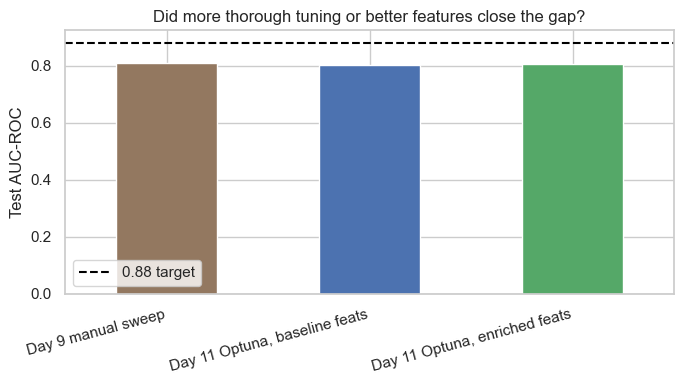

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
pd.Series({"Day 9 manual sweep": 0.808, "Day 11 Optuna, baseline feats": baseline_metrics["auc_roc"],
           "Day 11 Optuna, enriched feats": enriched_metrics["auc_roc"]}).plot(kind="bar", ax=ax, color=["#937860", "#4C72B0", "#55A868"])
ax.axhline(0.88, color="black", linestyle="--", label="0.88 target")
ax.set_ylabel("Test AUC-ROC")
ax.set_title("Did more thorough tuning or better features close the gap?")
ax.legend()
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

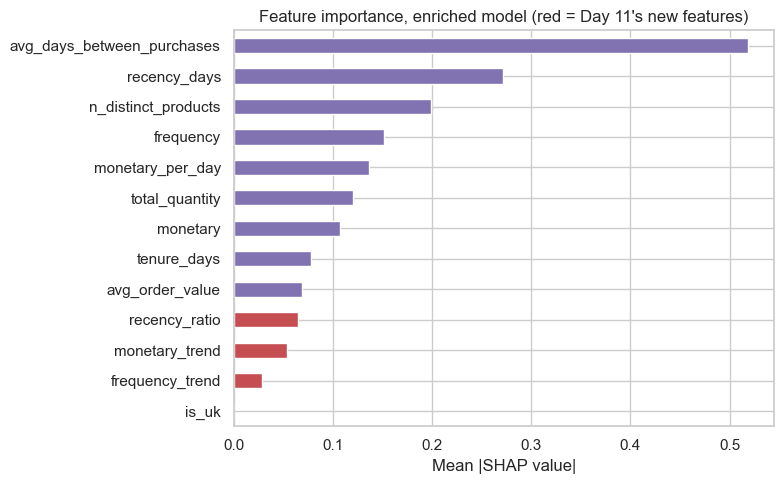

In [4]:
explainer = shap.TreeExplainer(enriched_model)
shap_values = explainer(enriched_Xtest)
mean_abs = pd.Series(np.abs(shap_values.values).mean(axis=0), index=enriched_Xtest.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#C44E52" if f in ("recency_ratio", "frequency_trend", "monetary_trend") else "#8172B2" for f in mean_abs.index]
mean_abs.plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Feature importance, enriched model (red = Day 11's new features)")
plt.tight_layout()
plt.show()

In [5]:
print("Optuna's winning hyperparameters (enriched feature set):")
for k, v in enriched_study.best_params.items():
    print(f"  {k}: {v}")

Optuna's winning hyperparameters (enriched feature set):
  max_depth: 3
  learning_rate: 0.2767883579966792
  n_estimators: 627
  subsample: 0.8306068124692322
  colsample_bytree: 0.93225697906213
  min_child_weight: 3
  gamma: 2.856073037069852
  reg_alpha: 0.3166346013482158
  reg_lambda: 0.0020406475691918144


## Day 11 findings summary

- Ran a Optuna search (60 trials, TPE sampler) on Day 9's original
  10-feature set: test AUC 0.801, essentially matching the manual sweep's
  0.808.
- Engineered 3 new features by Day 9's SHAP findings
  (`recency_ratio`, `frequency_trend`, `monetary_trend`)
- Ran the same 60-trial search on the enriched 13-feature set: test AUC
  0.806, a real but modest improvement (+0.5pp).
- None of the 3 new features rank in the top half of
  SHAP importance for the model that uses them.